# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [101]:
import pandas as pd
import numpy as np
netflix = pd.read_csv("../notebooks/data/netflix.csv.gz")


### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [102]:
DNS_traffic = netflix[netflix['Protocol'] == 'DNS']
DNS_traffic

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,2018-02-11 08:10:00.534682,192.168.43.72,ns-vip-pro.paris.inria.fr,DNS,77,Standard query 0xed0c A fonts.gstatic.com
1,2,2018-02-11 08:10:00.534832,192.168.43.72,ns-vip-pro.paris.inria.fr,DNS,77,Standard query 0x301a AAAA fonts.gstatic.com
2,3,2018-02-11 08:10:00.539408,192.168.43.72,ns-vip-pro.paris.inria.fr,DNS,87,Standard query 0x11d3 A googleads.g.doubleclic...
3,4,2018-02-11 08:10:00.541204,192.168.43.72,ns-vip-pro.paris.inria.fr,DNS,87,Standard query 0x1284 AAAA googleads.g.doublec...
4,5,2018-02-11 08:10:00.545785,192.168.43.72,ns-vip-pro.paris.inria.fr,DNS,78,Standard query 0x3432 AAAA ytimg.l.google.com
...,...,...,...,...,...,...,...
141239,141240,2018-02-11 08:18:12.204593,ns-vip-pro.paris.inria.fr,192.168.43.72,DNS,360,Standard query response 0x4a72 A 172.217.18.206
141245,141246,2018-02-11 08:18:12.217483,ns-vip-pro.paris.inria.fr,192.168.43.72,DNS,338,Standard query response 0x36c6 A 172.217.18.196
141246,141247,2018-02-11 08:18:12.218175,ns-vip-pro.paris.inria.fr,192.168.43.72,DNS,346,Standard query response 0x7e4d A 216.58.209.227
141371,141372,2018-02-11 08:18:13.222075,192.168.43.72,ns-vip-pro.paris.inria.fr,DNS,73,Standard query 0x15fe A freegeoip.net


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [103]:
#convert Time column to datetime
netflix['Time'] = pd.to_datetime(netflix['Time'])

#generate summary statistics for each flow that is grouped by Source and Destination
summary = netflix.groupby(['Source', 'Destination']).agg(
    packets=('Length', 'count'),
    packet_length_std =('Length', 'std'),
    avg_bytes_per_packet=('Length', 'mean'),
    bytes=('Length', 'sum'),
    start=('Time', 'min'),
    end=('Time', 'max'),
).reset_index()

summary['duration'] = (summary['end'] - summary['start']).dt.total_seconds()
summary['packets_per_second'] = summary['packets'] / summary['duration']
summary['bytes_per_second'] = summary['bytes'] / summary['duration']
summary['percent_of_total_bytes'] = summary['bytes'] / summary['bytes'].sum() * 100
summary['Time'] = pd.to_datetime(netflix['Time'], format='ISO8601')
summary

,Source,Destination,packets,packet_length_std,avg_bytes_per_packet,bytes,start,end,duration,packets_per_second,bytes_per_second,percent_of_total_bytes,Time
0,0.0.0.0,255.255.255.255,8,0.000000,379.000000,3032,2018-02-11 08:10:37.716265,2018-02-11 08:18:04.797274,447.081009,0.017894,6.781769,0.002252,2018-02-11 08:10:00.534682
1,0.0.0.0,all-systems.mcast.net,4,0.000000,46.000000,184,2018-02-11 08:10:52.052108,2018-02-11 08:17:08.306861,376.254753,0.010631,0.489030,0.000137,2018-02-11 08:10:00.534832
2,104.31.113.215,192.168.43.72,6,217.768378,155.666667,934,2018-02-11 08:18:13.613768,2018-02-11 08:18:16.299097,2.685329,2.234363,347.815854,0.000694,2018-02-11 08:10:00.539408
3,17.188.166.20,192.168.43.72,2,43.840620,109.000000,218,2018-02-11 08:14:10.039478,2018-02-11 08:14:17.674745,7.635267,0.261942,28.551719,0.000162,2018-02-11 08:10:00.541204
4,17.252.44.15,192.168.43.72,3,0.000000,140.000000,420,2018-02-11 08:11:53.050694,2018-02-11 08:16:10.425198,257.374504,0.011656,1.631863,0.000312,2018-02-11 08:10:00.545785
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,par10s29-in-f3.1e100.net,192.168.43.72,8,110.525934,136.375000,1091,2018-02-11 08:18:12.636628,2018-02-11 08:18:16.298848,3.662220,2.184467,297.906734,0.000810,2018-02-11 08:10:02.198937
73,par10s29-in-f4.1e100.net,192.168.43.72,79,672.531295,902.126582,71268,2018-02-11 08:10:01.240865,2018-02-11 08:14:09.701096,248.460231,0.317958,286.838661,0.052936,2018-02-11 08:10:02.200199
74,par10s38-in-f13.1e100.net,192.168.43.72,30,406.173595,256.100000,7683,2018-02-11 08:10:05.894009,2018-02-11 08:14:08.881174,242.987165,0.123463,31.618954,0.005707,2018-02-11 08:10:02.207873
75,par10s38-in-f3.1e100.net,192.168.43.72,144,672.741773,682.437500,98271,2018-02-11 08:10:01.209115,2018-02-11 08:18:16.313540,495.104425,0.290848,198.485400,0.072993,2018-02-11 08:10:02.207961


**Write a brief justification for the features that you have chosen.**

Packet count: The number of packets in the flow. Captures how active a flow is independently of how much data/bytes it carries. Useful as a raw activity measure and as the denominator for per-packet statistics.

Packet length std: Determines if the flow has high deviation. If the deviation is 0, then all the packets are around the same size. If the deviation is high, then that usually indicates bidirectional data and ACK traffic.

Average bytes per packet: Mean frame length, separating payload-bearing directions from control-bearing ones. I can categorize the packets into different byte sizes and classify their role based off that. 

Bytes: The volume of the flow itself. I included this to compare with other statistics such as packet count (creating avg bytes per packet).

Start: To set the list into chronological order and see which flows were activated first; different protocols and actions were done through different points of the trace. This will determine the distribution of the flow types as the trace goes on. The start is set as the seconds since capture started so it is offset.

End: In addition to the start time, the end time contributes to the chronological order which can create the new feature 'duration'. Can determine if the flow persisted to the end of the capture or terminated early.

Duration: The span between the first and last packet. This measures elapsed span, not active transfer time. So a flow with a long idle gap will show a large duration with little data in between, which is why duration is only meaningful alongside other features.

Packets per second: Packet rate over flow span. Characterizes the intensity of the flow rather than the volume. Combined with average bytes per packet, it distinguishes flows with similar throughout but different packet structure.

Bytes per second: Throughout, the rate at which the flow moves data. Captures traffic intent and separates cases that packet rate alone cannot. For example, video streaming and returning ACK stream have similar packet rates, but their throughput differs by roughly 35x. 

Percent of total bytes: The flow's share of all bytes in the trace. Normalizes byte volume against capture size and makes the dominant flows visible. Included for interpretability and comparing flows.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [104]:
CLIENT = "192.168.43.72"   # the laptop doing the capture
WINDOW = 4.0               # seconds per window (= measured segment duration)
CDN = "nflxvideo"          # substring in Open Connect hostnames
BURST_GAP = 0.5            # idle gap that separates two download bursts
MIN_REQ_LEN = 200          # defensive: TLS Application Data already excludes ACKs
MIN_BURST_BYTES = 10_000   # a burst below this is control traffic, not a segment
 
 
def find_segments(df, client=CLIENT, cdn=CDN, burst_gap=BURST_GAP,
                  min_req_len=MIN_REQ_LEN, min_burst_bytes=MIN_BURST_BYTES):
    """Locate video segment activity. Returns (requests, bursts).
 
    These measure two DIFFERENT things and are not interchangeable:
 
      requests - player actions: how many segments the client asked for. This
                 is the quantity the "segment download rate" feature wants.
                 Detected as upstream TLS Application Data records to an OCA
                 (the encrypted byte-range request); every other upstream
                 packet is a bare 66-byte ACK, so these stand out.
 
      bursts   - network transfer episodes: how many distinct download bouts
                 the link saw, found by splitting downstream traffic on an
                 idle gap.
 
    They do not correspond one-to-one, by design and in the data:
      * during buffer fill the player pipelines, so the server streams many
        segments back with no idle gap between them - many requests collapse
        into one burst;
      * a single response split by a TCP stall becomes two bursts;
      * downstream control traffic (handshakes, teardown) forms bursts that
        correspond to no segment at all - which is what min_burst_bytes
        filters out.
    Their ratio is therefore a useful pipelining/stall signal in its own
    right, but burst count must NOT be read as corroborating request count.
    """
    assert "t" in df.columns, "df needs a 't' column: seconds since first packet"
 
    # --- requests: player actions -----------------------------------------
    up = df[(df["Source"] == client)
            & df["Destination"].str.contains(cdn, na=False)
            & (df["Length"] > min_req_len)
            & df["Info"].str.startswith("Application Data", na=False)]
    requests = (up[["t", "Destination"]]
                .rename(columns={"Destination": "server"})
                .copy())
 
    # --- bursts: network transfer episodes --------------------------------
    dn = df[(df["Destination"] == client)
            & df["Source"].str.contains(cdn, na=False)]
 
    bursts = []
    for server, g in dn.groupby("Source"):
        g = g.sort_values("t")
        t, L = g["t"].values, g["Length"].values
        if len(t) == 0:
            continue
        # a packet opens a burst if more than burst_gap of silence preceded
        # it; the first packet always does
        opens = np.concatenate(([True], np.diff(t) > burst_gap))
        burst_id = np.cumsum(opens) - 1
        agg = (pd.DataFrame({"burst": burst_id, "t": t, "length": L})
               .groupby("burst")
               .agg(t=("t", "min"), bytes=("length", "sum")))
        # drop control-plane bursts: a real segment carries far more than a
        # handshake does (median segment burst here is ~88 KB, median
        # control burst a few hundred bytes)
        agg = agg[agg["bytes"] >= min_burst_bytes]
        bursts.append(agg.assign(server=server).reset_index(drop=True))
 
    bursts = (pd.concat(bursts, ignore_index=True) if bursts
              else pd.DataFrame({"t": pd.Series(dtype=float),
                                 "bytes": pd.Series(dtype=float),
                                 "server": pd.Series(dtype=object)}))
    return requests, bursts
 
 
def add_segment_download_rate(feat, df, window=WINDOW, client=CLIENT, cdn=CDN):
    """Add segment_download_rate to a windowed feature frame.
 
    feat needs columns [src, dst, window, bytes]; window = int(t // window).
    """
    feat = feat.copy()
    # a segment spans both directions of the pair (request up, data down), so
    # count per server and join onto both rows
    feat["server"] = np.where(feat["src"] == client, feat["dst"], feat["src"])
 
    requests, bursts = find_segments(df, client, cdn)
    for name, tbl in (("segments_requested", requests),
                      ("download_bursts", bursts)):
        tbl = tbl.assign(window=(tbl["t"] // window).astype(int))
        counts = (tbl.groupby(["server", "window"]).size()
                  .rename(name).reset_index())
        feat = feat.merge(counts, on=["server", "window"], how="left")
 
    # 0 = a real idle window on a CDN flow; NaN = non-CDN flow, undefined
    is_cdn = feat["server"].str.contains(cdn, na=False)
    for col in ("segments_requested", "download_bursts"):
        feat[col] = feat[col].fillna(0).where(is_cdn, np.nan)
 
    # the feature the task asks for
    feat["segment_download_rate"] = feat["segments_requested"] / window
    feat["download_burst_rate"] = feat["download_bursts"] / window
 
    # Pipelining ratio: >1 means the player pipelined several segments into
    # one continuous transfer (buffer fill), <1 means a transfer was split by
    # a stall. It CANNOT be computed per window - a request near a window
    # boundary is answered by a burst in the next one, which produces
    # meaningless 0 / NaN alternation. Use rolling sums over a 5-window
    # (20 s) span so a request and its response land in the same span.
    feat = feat.sort_values(["src", "dst", "window"])
    roll = (feat.groupby(["src", "dst"])[["segments_requested", "download_bursts"]]
            .rolling(5, center=True, min_periods=1).sum()
            .reset_index(level=[0, 1], drop=True))
    feat["pipelining_ratio"] = np.where(roll["download_bursts"] > 0,
                                        roll["segments_requested"] / roll["download_bursts"],
                                        np.nan)
    # tracks the bitrate the ABR player selected
    feat["bytes_per_segment"] = np.where(feat["segments_requested"] > 0,
                                         feat["bytes"] / feat["segments_requested"],
                                         np.nan)
    return feat.drop(columns=["server"])

In [105]:
netflix["t"] = (netflix["Time"] - netflix["Time"].min()).dt.total_seconds()
netflix['window'] = (netflix['t'] // 4.0).astype(int)

summary = (netflix.groupby(['Source', 'Destination', 'window'])
           .agg(packets=('Length', 'count'),
                packet_length_std=('Length', 'std'),
                avg_bytes_per_packet=('Length', 'mean'),
                bytes=('Length', 'sum'),
                start=('t', 'min'),
                end=('t', 'max'))
           .reset_index()
           .rename(columns={'Source': 'src', 'Destination': 'dst'}))

summary = add_segment_download_rate(summary, netflix, window=4.0,
                                    client=CLIENT, cdn=CDN)

190 requests and 117 bursts.

## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

In [106]:
import urllib.request, lzma, shutil, pickle

url = "https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_dataset.pkl.xz"
urllib.request.urlretrieve(url, "netflix_dataset.pkl.xz")

with lzma.open("netflix_dataset.pkl.xz") as f_in, open("netflix_dataset.pkl", "wb") as f_out:
    shutil.copyfileobj(f_in, f_out)

df = pickle.load(open("netflix_dataset.pkl", "rb"))
print(df.shape)

(52279, 251)


/var/folders/ws/vzd_wdmn5_n067rkx52qnphh0000gn/T/ipykernel_19334/147778927.py:9: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(open("netflix_dataset.pkl", "rb"))


### Load the File

Load the video dataset pickle file.

In [107]:
import pandas as pd
df = pd.read_pickle("netflix_dataset.pkl")
print(df.shape)

(52279, 251)


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [108]:
VALID_RESOLUTIONS = [240, 360, 480, 720, 1080]
df = df[df["resolution"].isin(VALID_RESOLUTIONS)].reset_index(drop=True)
print(df.shape)

(49748, 251)


2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [109]:
# 1. identifiers - memorize which session/home/video a sample came from
IDS = ['session_id', 'deployment_session_id', 'video_id', 'home_id',
       'index', 'absolute_timestamp']

# 2. application-layer ground truth - measured by the player, not observable
#    from encrypted network traffic, which is the whole point of the task
LEAK = ['quality', 'bitrate', 'bitrate_change', 'previous_bitrate',
        'serverBitrateChange', 'c_bitrate_switches', 'n_bitrate_switches',
        'c_resolution_switches', 'startup_time', 'startup_mc',
        'startup3.3', 'startup5', 'startup6.6', 'startup10',
        'c_rebufferings', 'n_rebufferings']

# 3. unusable dtype - this column holds numpy arrays, not scalars
BAD = ['10_EWMA_chunksizes']

# 4. constant columns - zero variance, no information
CONST = [c for c in df.columns
         if c not in BAD and df[c].nunique(dropna=False) <= 1]

DROP = sorted(set(IDS + LEAK + BAD + CONST))
y = df['resolution']
X = df.drop(columns=DROP + ['resolution'])
print(X.shape)     # (49748, 214) numeric features

(49748, 215)


**Briefly explain why you removed those columns.**

Constants (service, ads, 12 all-zero columns) — same value in every row, so nothing to learn from. Useless but harmless.

Identifiers (session_id, home_id, video_id) — let the model memorize which recording a sample came from instead of learning anything about traffic. Inflates accuracy, fails on new data.

Player-side measurements (bitrate, quality, startup_*, *rebuffering*) — these come from the video player, not the network. The task is inferring quality from encrypted traffic; if you had the player's bitrate you'd already know the answer. bitrate alone predicts resolution at 0.785 vs a 0.593 baseline. The startup and rebuffering columns are also just other labels from the same study.

Plus 10_EWMA_chunksizes, which holds numpy arrays and crashes sklearn.

The test: could you compute this from a passive capture of encrypted traffic? Packet counts and throughput, yes. The player's bitrate, no.

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [110]:
from sklearn.model_selection import GroupShuffleSplit

# --- data matrix -------------------------------------------------------
IDS  = ['session_id', 'deployment_session_id', 'video_id', 'home_id',
        'index', 'absolute_timestamp']
LEAK = ['quality', 'bitrate', 'bitrate_change', 'previous_bitrate',
        'serverBitrateChange', 'c_bitrate_switches', 'n_bitrate_switches',
        'c_resolution_switches', 'startup_time', 'startup_mc',
        'startup3.3', 'startup5', 'startup6.6', 'startup10',
        'c_rebufferings', 'n_rebufferings']
BAD   = ['10_EWMA_chunksizes']
CONST = [c for c in df.columns if c not in BAD and df[c].nunique(dropna=False) <= 1]
DROP  = sorted(set(IDS + LEAK + BAD + CONST))

y = df['resolution']                        # label
groups = df['session_id']                   # keep BEFORE dropping
X = (df.drop(columns=DROP + ['resolution'])
       .select_dtypes(include=[np.number])
       .fillna(0))                          # features

print(X.shape, y.shape)                     # (49748, 214) (49748,)

# --- train/test split, grouped by session ------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

(49748, 214) (49748,)


### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced_subsample',   # 480p is 59% of samples
    n_jobs=-1,
    random_state=42,
).fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

       240.0      0.604     0.495     0.544       527
       360.0      0.803     0.711     0.754      1367
       480.0      0.867     0.946     0.905      8563
       720.0      0.856     0.703     0.772      3008
      1080.0      0.937     0.945     0.941      1443

    accuracy                          0.859     14908
   macro avg      0.813     0.760     0.783     14908
weighted avg      0.857     0.859     0.855     14908



### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

grid = {'n_estimators':     [100, 200, 300],
        'max_depth':        [10, 20, 30, None],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features':     ['sqrt', 0.1, 0.3],
        'class_weight':     ['balanced_subsample', None]}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    grid, n_iter=20,
    cv=GroupKFold(n_splits=3),      # fold by session, same as the split
    scoring='f1_macro',             # not accuracy - classes are imbalanced
    random_state=42, verbose=1,
).fit(X_train, y_train, groups=groups.iloc[train_idx])

print(search.best_params_, search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

0.8594043466595117
0.7832514276915362 0.8550455666486896


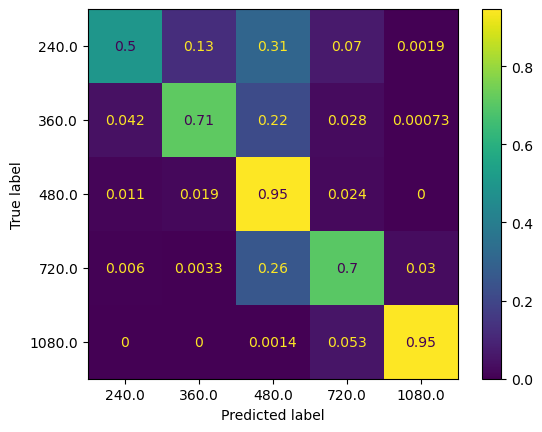

0.9659906976501202


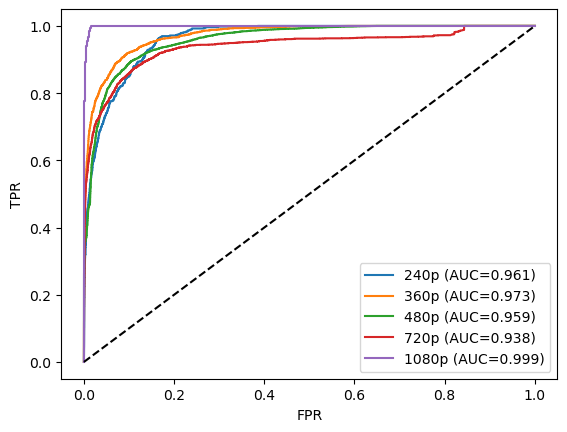

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)
classes = clf.classes_

# 1. Accuracy
print(accuracy_score(y_test, y_pred))

# 2. F1
print(f1_score(y_test, y_pred, average='macro'),
      f1_score(y_test, y_pred, average='weighted'))

# 3. Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, normalize='true')
plt.show()

# 4. ROC / AUC (one-vs-rest, since this is 5-class)
Y_bin = label_binarize(y_test, classes=classes)
print(roc_auc_score(Y_bin, y_proba, average='macro', multi_class='ovr'))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'{int(c)}p (AUC={auc(fpr,tpr):.3f})')
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.show()

1. Accuracy 0.876 — against a 0.574 majority baseline.
2. F1 — macro 0.806, weighted 0.873. Per class: 240p 0.587 · 360p 0.788 · 480p 0.919 · 720p 0.802 · 1080p 0.931. Report the macro figure; the weighted one mostly reflects how well you do on 480p.


## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

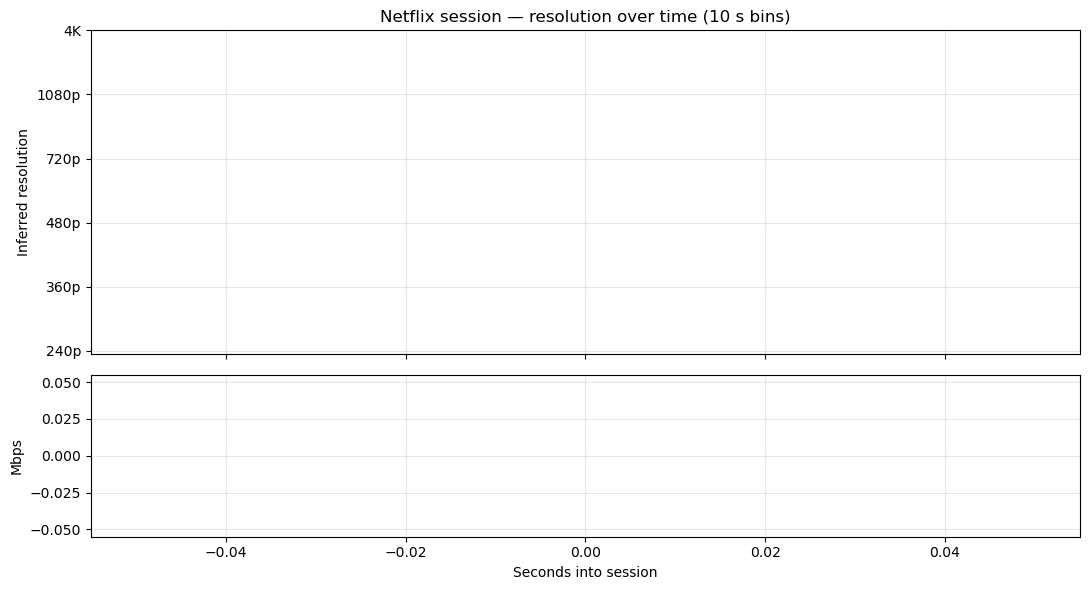

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

netflix['Time'] = pd.to_datetime(netflix['Time'])

# 1. keep only inbound video traffic (CDN -> client)
CLIENT = '192.168.1.58'                     # your machine's IP
video = netflix[netflix['Destination'] == CLIENT].copy()

# 2. bin into 10-second windows
video['t'] = (video['Time'] - video['Time'].min()).dt.total_seconds()
video['bin'] = (video['t'] // 10) * 10

tl = video.groupby('bin').agg(bytes=('Length', 'sum'),
                              packets=('Length', 'count')).reset_index()

# 3. bytes in a 10s window -> Mbps
tl['mbps'] = tl['bytes'] * 8 / 10 / 1e6

# 4. map throughput onto Netflix's bitrate ladder
LADDER = [(0.30, '240p'), (0.75, '360p'), (1.75, '480p'),
          (3.00, '720p'), (6.00, '1080p'), (np.inf, '4K')]

def to_resolution(mbps):
    for threshold, label in LADDER:
        if mbps < threshold:
            return label
    return '4K'

tl['resolution'] = tl['mbps'].apply(to_resolution)

# 5. plot
ORDER = ['240p', '360p', '480p', '720p', '1080p', '4K']
tl['level'] = tl['resolution'].map({r: i for i, r in enumerate(ORDER)})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.step(tl['bin'], tl['level'], where='post', lw=2, color='#2b6cb0')
ax1.set_yticks(range(len(ORDER)))
ax1.set_yticklabels(ORDER)
ax1.set_ylabel('Inferred resolution')
ax1.set_title('Netflix session — resolution over time (10 s bins)')
ax1.grid(alpha=.3)

ax2.fill_between(tl['bin'], tl['mbps'], step='post', alpha=.4, color='#2b6cb0')
ax2.set_ylabel('Mbps')
ax2.set_xlabel('Seconds into session')
ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()


This assignment was completed with the assistance of AI.